测试数据和训练数据分组，数据分batch

In [ ]:
#单GRU
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import accuracy_score
from joblib import load  # 添加导入

# 设备配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 修改后的数据加载部分
def load_data():
    # 从本地加载预处理好的数据集
    train_set = load('train_set')  # 加载训练集
    val_set = load('val_set')      # 加载验证集
    test_set = load('test_set')    # 加载测试集

    # 转换为numpy数组
    train_data = train_set.values
    val_data = val_set.values
    test_data = test_set.values

    def process_data(data):
        features = data[:, :-1].astype(np.float32)
        labels = data[:, -1].astype(np.long)
        features = np.expand_dims(features, axis=2)
        return features, labels

    X_train, y_train = process_data(train_data)
    X_val, y_val = process_data(val_data)
    X_test, y_test = process_data(test_data)

    # 转换为TensorDataset
    train_dataset = TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train))
    val_dataset = TensorDataset(torch.Tensor(X_val), torch.LongTensor(y_val))
    test_dataset = TensorDataset(torch.Tensor(X_test), torch.LongTensor(y_test))

    return train_dataset, val_dataset, test_dataset





# GRU模型定义
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, num_classes=10):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # 初始化隐藏状态
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        # 前向传播GRU
        out, _ = self.gru(x, h0)  # out: (batch_size, seq_length, hidden_size)
        
        # 取最后一个时间步的输出
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

# 训练参数设置
batch_size = 32
learning_rate = 0.001
num_epochs = 50

# 加载数据（修改调用方式）
train_dataset, val_dataset, test_dataset = load_data()  # 无参数调用

# 创建DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# 初始化模型
model = GRUModel().to(device)

# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# 训练循环
best_val_acc = 0
for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # 前向传播
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 反向传播与优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    
    # 验证阶段
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    # 计算统计量
    train_loss = train_loss / len(train_loader.dataset)
    val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100 * correct / total
    
    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_gru_model.pth')
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

# 测试模型
model.load_state_dict(torch.load('best_gru_model.pth'))
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f'Test Accuracy: {100 * test_correct / test_total:.2f}%')

C:\Users\13911\AppData\Local\Temp\ipykernel_3808\233152934.py:25: DeprecationWarning: `np.long` is a deprecated alias for `np.compat.long`. To silence this warning, use `np.compat.long` by itself. In the likely event your code does not need to work on Python 2 you can use the builtin `int` for which `np.compat.long` is itself an alias. Doing this will not modify any behaviour and is safe. When replacing `np.long`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  labels = data[:, -1].astype(np.long)


Epoch [1/50], Train Loss: 2.3109, Val Loss: 2.3077, Val Acc: 9.01%
Epoch [2/50], Train Loss: 2.3045, Val Loss: 2.3062, Val Acc: 9.23%
Epoch [3/50], Train Loss: 2.3039, Val Loss: 2.3067, Val Acc: 9.23%
Epoch [4/50], Train Loss: 2.2821, Val Loss: 2.0003, Val Acc: 16.52%
Epoch [5/50], Train Loss: 1.8394, Val Loss: 1.7550, Val Acc: 18.24%
Epoch [6/50], Train Loss: 1.7726, Val Loss: 1.7494, Val Acc: 16.95%
Epoch [7/50], Train Loss: 1.7622, Val Loss: 1.7424, Val Acc: 16.74%
Epoch [8/50], Train Loss: 1.7536, Val Loss: 1.7234, Val Acc: 20.39%
Epoch [9/50], Train Loss: 1.7447, Val Loss: 1.7276, Val Acc: 19.53%
Epoch [10/50], Train Loss: 1.8102, Val Loss: 1.7532, Val Acc: 20.60%
Epoch [11/50], Train Loss: 1.7757, Val Loss: 1.7346, Val Acc: 16.74%
Epoch [12/50], Train Loss: 1.8092, Val Loss: 1.7946, Val Acc: 19.53%
Epoch [13/50], Train Loss: 1.8055, Val Loss: 1.7905, Val Acc: 17.38%
Epoch [14/50], Train Loss: 1.7878, Val Loss: 1.7388, Val Acc: 16.95%
Epoch [15/50], Train Loss: 1.7396, Val Loss: 1

In [5]:
#双GRU
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import accuracy_score
from joblib import load  # 添加导入

# 设备配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 修改后的数据加载部分
def load_data():
    # 从本地加载预处理好的数据集
    train_set = load('train_set')  # 加载训练集
    val_set = load('val_set')      # 加载验证集
    test_set = load('test_set')    # 加载测试集

    # 转换为numpy数组
    train_data = train_set.values
    val_data = val_set.values
    test_data = test_set.values

    def process_data(data):
        features = data[:, :-1].astype(np.float32)
        labels = data[:, -1].astype(np.long)
        features = np.expand_dims(features, axis=2)
        return features, labels

    X_train, y_train = process_data(train_data)
    X_val, y_val = process_data(val_data)
    X_test, y_test = process_data(test_data)

    # 转换为TensorDataset
    train_dataset = TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train))
    val_dataset = TensorDataset(torch.Tensor(X_val), torch.LongTensor(y_val))
    test_dataset = TensorDataset(torch.Tensor(X_test), torch.LongTensor(y_test))

    return train_dataset, val_dataset, test_dataset




# 双向GRU模型
class BiGRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, num_classes=10):
        super(BiGRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, 
                         hidden_size, 
                         num_layers, 
                         batch_first=True, 
                         dropout=0.2,
                         bidirectional=True)
        self.fc = nn.Linear(hidden_size*2, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers*2, x.size(0), self.hidden_size).to(device)
        out, _ = self.gru(x, h0)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

# 训练参数设置
batch_size = 32
learning_rate = 0.001
num_epochs = 50

# 加载数据（修改调用方式）
train_dataset, val_dataset, test_dataset = load_data()  # 无参数调用

# 创建DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# 初始化模型
model = GRUModel().to(device)

# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# 训练循环
best_val_acc = 0
for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # 前向传播
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 反向传播与优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    
    # 验证阶段
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    # 计算统计量
    train_loss = train_loss / len(train_loader.dataset)
    val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100 * correct / total
    
    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_gru_model.pth')
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

# 测试模型
model.load_state_dict(torch.load('best_gru_model.pth'))
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f'Test Accuracy: {100 * test_correct / test_total:.2f}%')

C:\Users\13911\AppData\Local\Temp\ipykernel_3808\2707234120.py:25: DeprecationWarning: `np.long` is a deprecated alias for `np.compat.long`. To silence this warning, use `np.compat.long` by itself. In the likely event your code does not need to work on Python 2 you can use the builtin `int` for which `np.compat.long` is itself an alias. Doing this will not modify any behaviour and is safe. When replacing `np.long`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  labels = data[:, -1].astype(np.long)


Epoch [1/50], Train Loss: 2.3066, Val Loss: 2.3083, Val Acc: 9.23%
Epoch [2/50], Train Loss: 2.3060, Val Loss: 2.3069, Val Acc: 9.01%
Epoch [3/50], Train Loss: 2.3033, Val Loss: 2.3047, Val Acc: 10.52%
Epoch [4/50], Train Loss: 2.3021, Val Loss: 2.2998, Val Acc: 7.73%
Epoch [5/50], Train Loss: 2.0737, Val Loss: 1.8024, Val Acc: 20.82%
Epoch [6/50], Train Loss: 1.8694, Val Loss: 1.7688, Val Acc: 21.03%
Epoch [7/50], Train Loss: 1.7772, Val Loss: 1.7681, Val Acc: 17.60%
Epoch [8/50], Train Loss: 1.7702, Val Loss: 1.7356, Val Acc: 19.31%
Epoch [9/50], Train Loss: 1.7505, Val Loss: 1.7277, Val Acc: 20.39%
Epoch [10/50], Train Loss: 1.7415, Val Loss: 1.7210, Val Acc: 22.32%
Epoch [11/50], Train Loss: 1.7334, Val Loss: 1.7241, Val Acc: 21.46%
Epoch [12/50], Train Loss: 1.7354, Val Loss: 1.7219, Val Acc: 20.60%
Epoch [13/50], Train Loss: 1.7247, Val Loss: 1.7169, Val Acc: 21.46%
Epoch [14/50], Train Loss: 1.7760, Val Loss: 1.9252, Val Acc: 15.88%
Epoch [15/50], Train Loss: 2.2662, Val Loss: 1

In [16]:
#CNN+BiGRU
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import accuracy_score
from joblib import load  # 添加导入

# 设备配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 修改后的数据加载部分
def load_data():
    # 从本地加载预处理好的数据集
    train_set = load('train_set')  # 加载训练集
    val_set = load('val_set')      # 加载验证集
    test_set = load('test_set')    # 加载测试集

    # 转换为numpy数组
    train_data = train_set.values
    val_data = val_set.values
    test_data = test_set.values

    def process_data(data):
        features = data[:, :-1].astype(np.float32)
        labels = data[:, -1].astype(np.long)
        features = np.expand_dims(features, axis=2)
        return features, labels

    X_train, y_train = process_data(train_data)
    X_val, y_val = process_data(val_data)
    X_test, y_test = process_data(test_data)

    # 转换为TensorDataset
    train_dataset = TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train))
    val_dataset = TensorDataset(torch.Tensor(X_val), torch.LongTensor(y_val))
    test_dataset = TensorDataset(torch.Tensor(X_test), torch.LongTensor(y_test))

    return train_dataset, val_dataset, test_dataset



# CNN+BiGRU混合架构
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.gru = nn.GRU(64, 128, bidirectional=True)
        self.fc = nn.Linear(128*2, 10)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (batch, channels, length)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)  # 恢复时序维度
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

# 训练参数设置
batch_size = 32
learning_rate = 0.001
num_epochs = 50

# 加载数据（修改调用方式）
train_dataset, val_dataset, test_dataset = load_data()  # 无参数调用

# 创建DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# 初始化模型
model = GRUModel().to(device)

# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# 训练循环
best_val_acc = 0
for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # 前向传播
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 反向传播与优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    
    # 验证阶段
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    # 计算统计量
    train_loss = train_loss / len(train_loader.dataset)
    val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100 * correct / total
    
    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_gru_model.pth')
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

# 测试模型
model.load_state_dict(torch.load('best_gru_model.pth'))
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f'Test Accuracy: {100 * test_correct / test_total:.2f}%')

C:\Users\13911\AppData\Local\Temp\ipykernel_3808\2152920882.py:26: DeprecationWarning: `np.long` is a deprecated alias for `np.compat.long`. To silence this warning, use `np.compat.long` by itself. In the likely event your code does not need to work on Python 2 you can use the builtin `int` for which `np.compat.long` is itself an alias. Doing this will not modify any behaviour and is safe. When replacing `np.long`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  labels = data[:, -1].astype(np.long)


Epoch [1/50], Train Loss: 2.3057, Val Loss: 2.3074, Val Acc: 9.23%
Epoch [2/50], Train Loss: 2.3051, Val Loss: 2.3090, Val Acc: 7.73%
Epoch [3/50], Train Loss: 2.3067, Val Loss: 2.3063, Val Acc: 9.66%
Epoch [4/50], Train Loss: 2.3023, Val Loss: 2.3046, Val Acc: 10.52%
Epoch [5/50], Train Loss: 2.2801, Val Loss: 2.2438, Val Acc: 9.87%
Epoch [6/50], Train Loss: 2.1232, Val Loss: 2.4940, Val Acc: 15.45%
Epoch [7/50], Train Loss: 2.1739, Val Loss: 1.8067, Val Acc: 19.31%
Epoch [8/50], Train Loss: 1.7354, Val Loss: 1.7498, Val Acc: 25.75%
Epoch [9/50], Train Loss: 1.5558, Val Loss: 1.4011, Val Acc: 30.90%
Epoch [10/50], Train Loss: 1.3904, Val Loss: 1.3732, Val Acc: 30.47%


KeyboardInterrupt: 

C:\Users\13911\AppData\Local\Temp\ipykernel_3808\4273925121.py:29: DeprecationWarning: `np.long` is a deprecated alias for `np.compat.long`. To silence this warning, use `np.compat.long` by itself. In the likely event your code does not need to work on Python 2 you can use the builtin `int` for which `np.compat.long` is itself an alias. Doing this will not modify any behaviour and is safe. When replacing `np.long`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  labels = data[:, -1].astype(np.long)


Epoch [1/50], Train Loss: 2.2375, Train Acc: 13.43%, Val Loss: 2.1851, Val Acc: 17.38%
Epoch [2/50], Train Loss: 2.1049, Train Acc: 20.78%, Val Loss: 2.1350, Val Acc: 19.53%
Epoch [3/50], Train Loss: 2.0331, Train Acc: 23.79%, Val Loss: 2.0953, Val Acc: 21.03%
Epoch [4/50], Train Loss: 1.9780, Train Acc: 27.71%, Val Loss: 2.0253, Val Acc: 25.11%
Epoch [5/50], Train Loss: 1.9151, Train Acc: 28.33%, Val Loss: 1.9627, Val Acc: 28.33%
Epoch [6/50], Train Loss: 1.8654, Train Acc: 31.02%, Val Loss: 1.9861, Val Acc: 29.61%
Epoch [7/50], Train Loss: 1.8502, Train Acc: 31.21%, Val Loss: 1.9105, Val Acc: 28.11%
Epoch [8/50], Train Loss: 1.8136, Train Acc: 33.05%, Val Loss: 1.9471, Val Acc: 28.33%
Epoch [9/50], Train Loss: 1.7982, Train Acc: 31.82%, Val Loss: 1.8790, Val Acc: 27.68%
Epoch [10/50], Train Loss: 1.7840, Train Acc: 33.17%, Val Loss: 1.8873, Val Acc: 28.76%
Epoch [11/50], Train Loss: 1.7683, Train Acc: 33.60%, Val Loss: 1.8957, Val Acc: 28.97%
Epoch [12/50], Train Loss: 1.7658, Train 

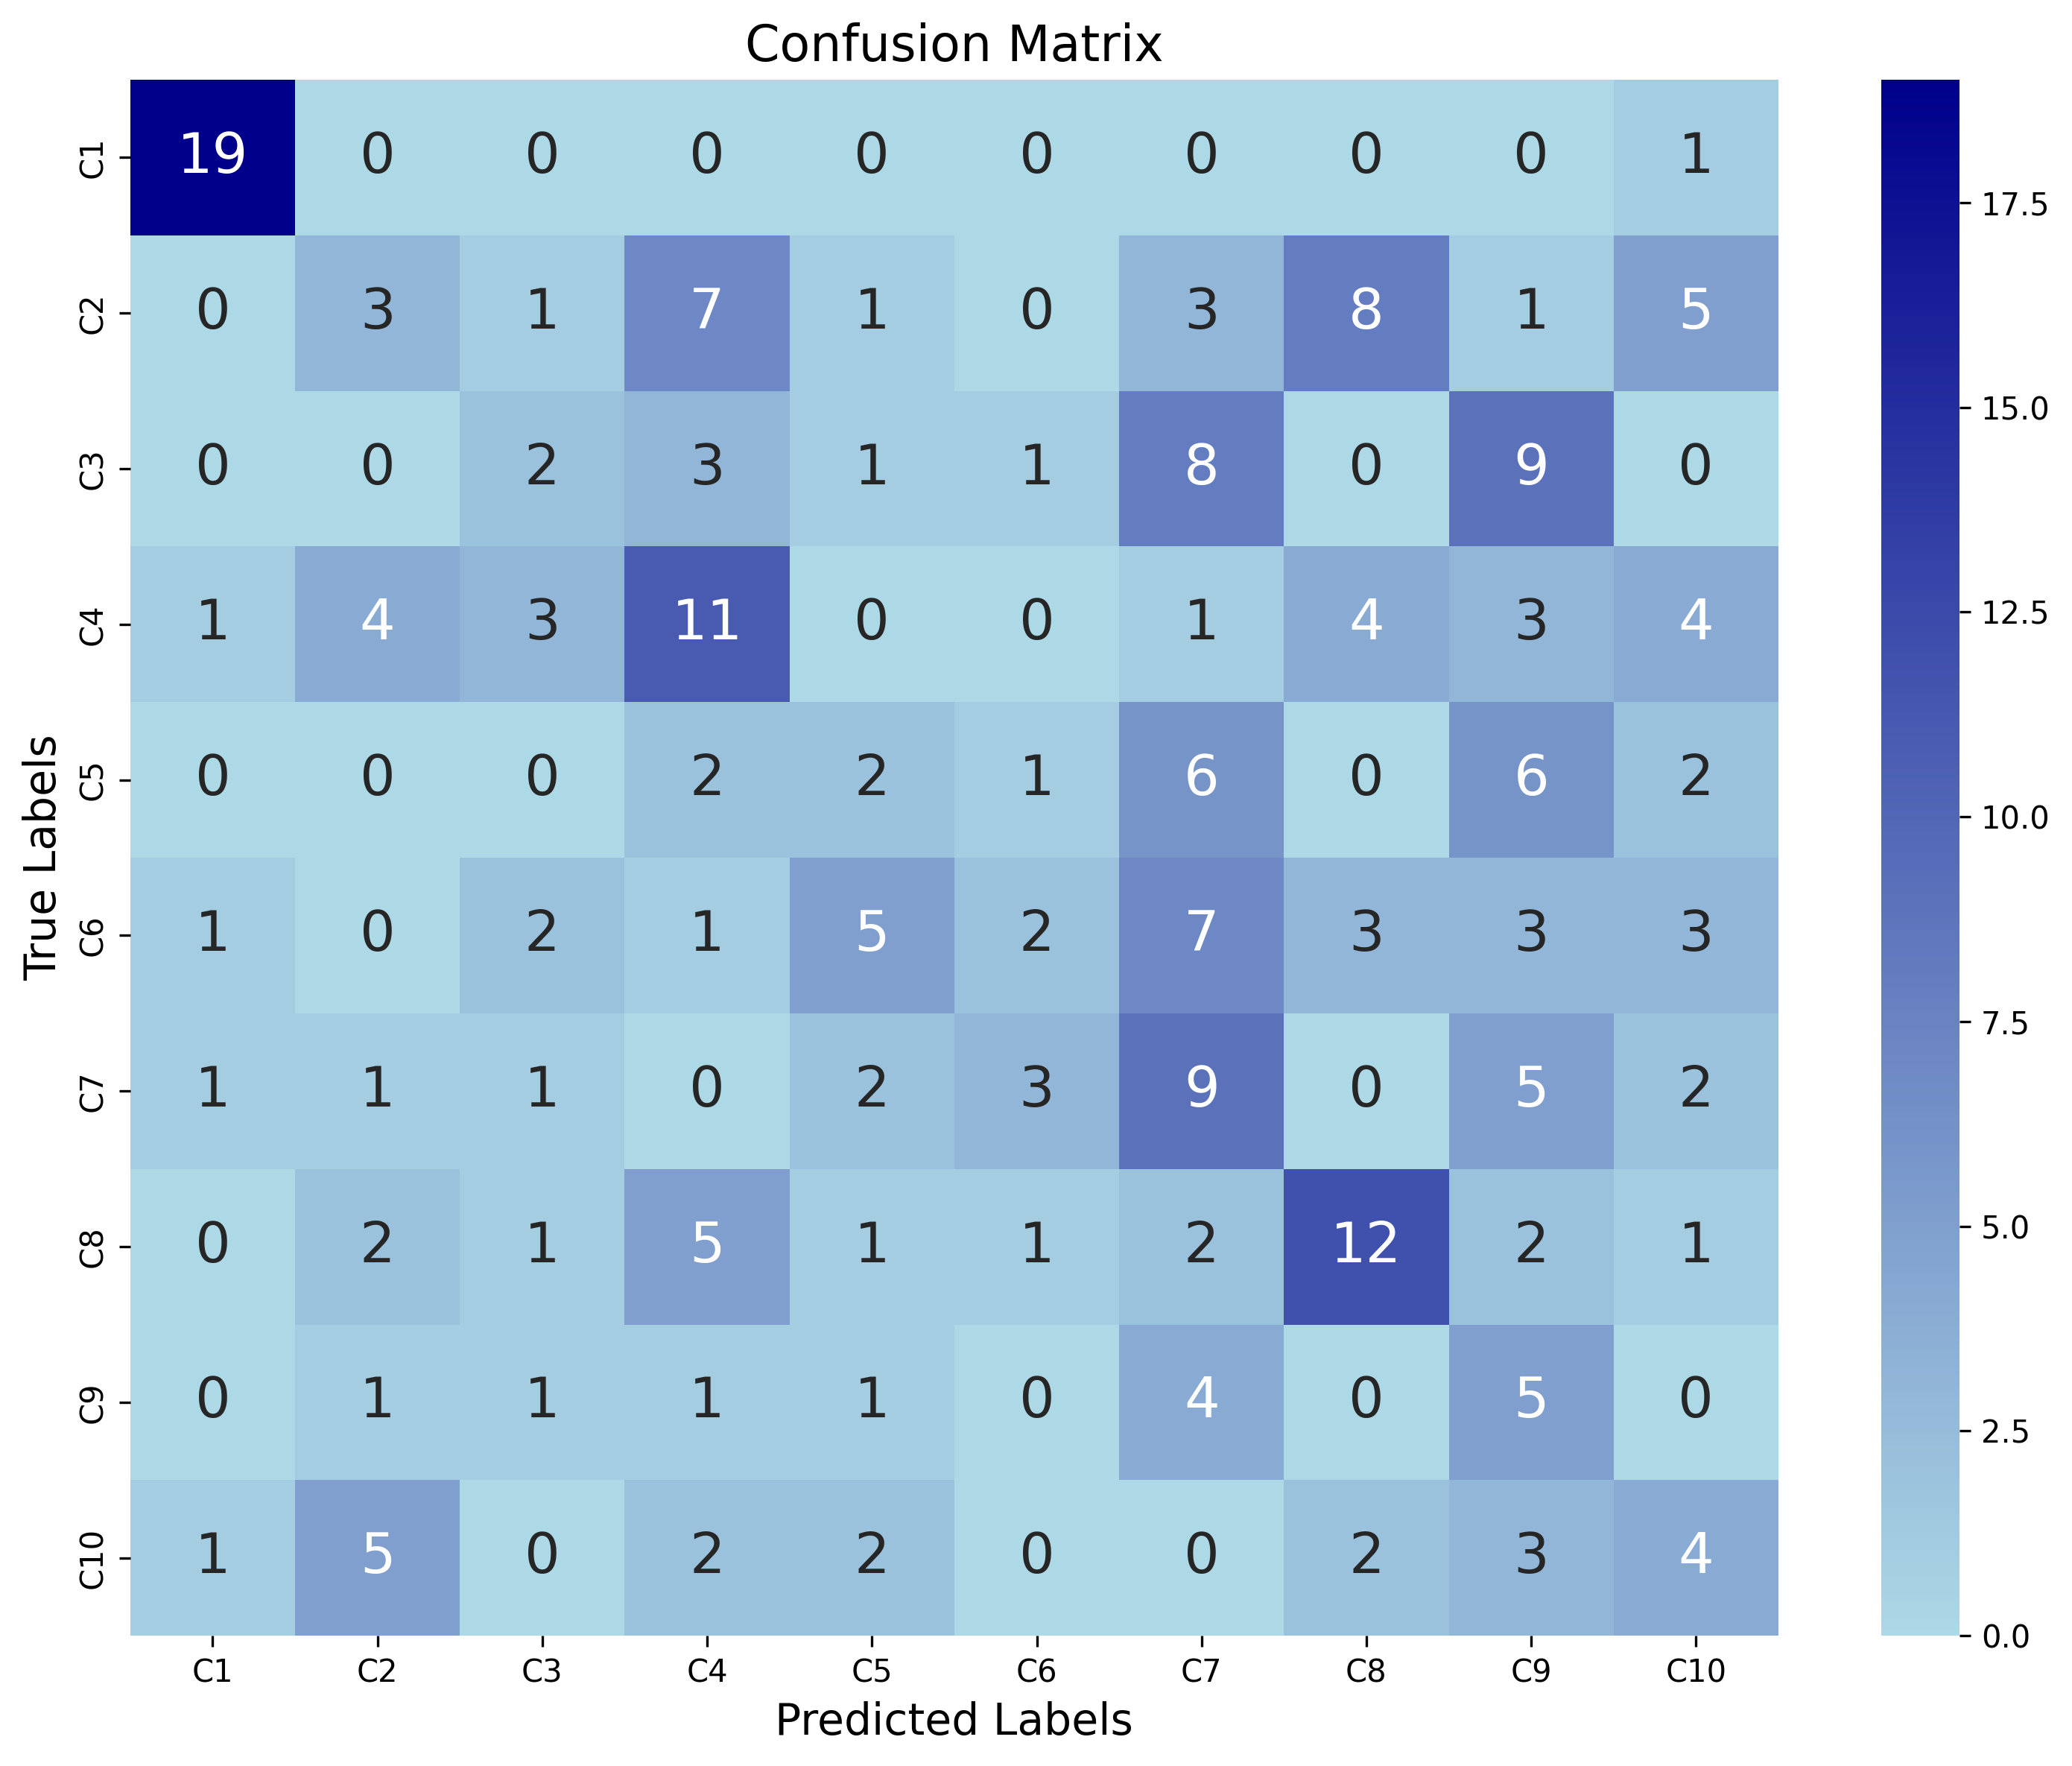

In [18]:
# CNN+BiGRU
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from joblib import load, dump  # 添加dump导入
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# 设备配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 修改后的数据加载部分
def load_data():
    # 从本地加载预处理好的数据集
    train_set = load('train_set')  # 加载训练集
    val_set = load('val_set')      # 加载验证集
    test_set = load('test_set')    # 加载测试集

    # 转换为numpy数组
    train_data = train_set.values
    val_data = val_set.values
    test_data = test_set.values

    def process_data(data):
        features = data[:, :-1].astype(np.float32)
        labels = data[:, -1].astype(np.long)
        features = np.expand_dims(features, axis=2)
        return features, labels

    X_train, y_train = process_data(train_data)
    X_val, y_val = process_data(val_data)
    X_test, y_test = process_data(test_data)

    # 转换为TensorDataset
    train_dataset = TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train))
    val_dataset = TensorDataset(torch.Tensor(X_val), torch.LongTensor(y_val))
    test_dataset = TensorDataset(torch.Tensor(X_test), torch.LongTensor(y_test))

    return train_dataset, val_dataset, test_dataset

# CNN+BiGRU混合架构
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.gru = nn.GRU(64, 128, bidirectional=True)
        self.fc = nn.Linear(128*2, 10)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (batch, channels, length)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)  # 恢复时序维度
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

# 训练参数设置
batch_size = 32
learning_rate = 0.003
num_epochs = 50

# 加载数据（修改调用方式）
train_dataset, val_dataset, test_dataset = load_data() 

# 创建DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# 初始化模型（修正模型名称）
model = HybridModel().to(device)

# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# 初始化记录列表
train_losses = []
train_accs = []
val_losses = []
val_accs = []

# 训练循环
best_val_acc = 0
for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # 前向传播
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 反向传播与优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # 统计指标
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    # 计算训练指标
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = 100 * train_correct / train_total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # 验证阶段
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    # 计算验证指标
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = 100 * val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)
    
    # 保存最佳模型
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_gru_model.pth')
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')

# 保存训练指标
dump(train_losses, './matfiles/train_loss')
dump(train_accs, './matfiles/train_acc')
dump(val_losses, './matfiles/validate_loss')
dump(val_accs, './matfiles/validate_acc')

# 测试模型
model.load_state_dict(torch.load('best_gru_model.pth'))
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 计算分类报告
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# 计算混淆矩阵
confusion_mat = confusion_matrix(all_labels, all_preds)

# 绘制混淆矩阵
label_mapping = {
    0: "C1",1: "C2",2: "C3",3: "C4",4: "C5",
    5: "C6",6: "C7",7: "C8",8: "C9",9: "C10",
}

colors = ["#ADD8E6", "#00008B"]
cmap = LinearSegmentedColormap.from_list("custom_blues", colors)

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(confusion_mat,  
            xticklabels=label_mapping.values(), 
            yticklabels=label_mapping.values(),
            annot=True,
            annot_kws={'size': 18}, 
            fmt='d', 
            cmap=cmap)
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

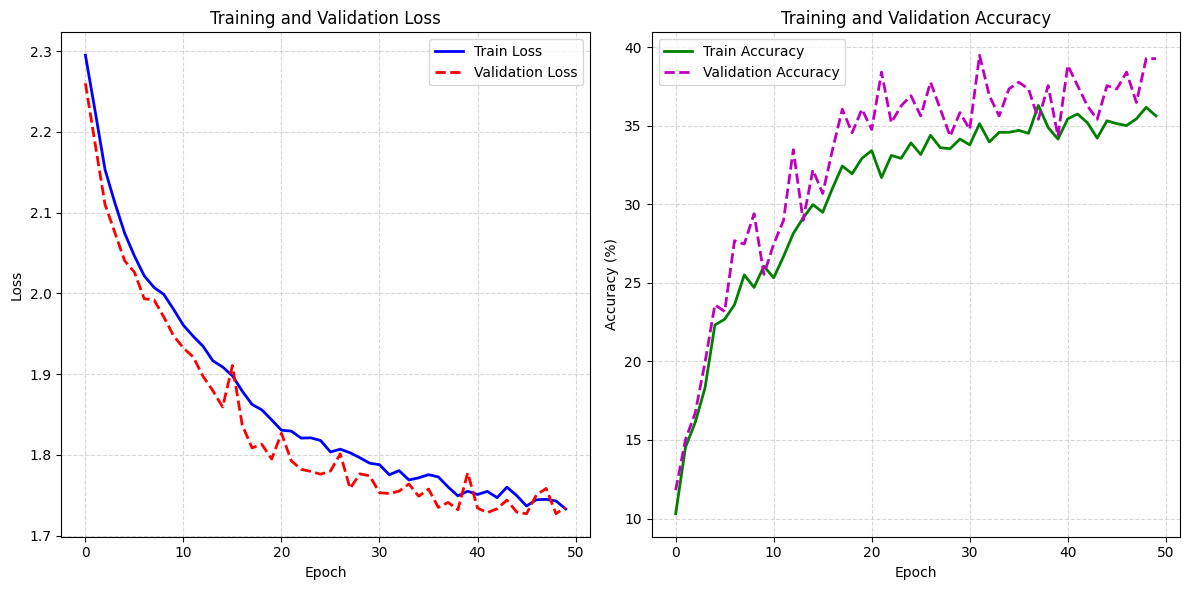

In [14]:
from joblib import load
import matplotlib.pyplot as plt
import numpy as np

# 加载保存的指标数据
train_loss = load('./matfiles/train_loss')
train_acc = load('./matfiles/train_acc')
val_loss = load('./matfiles/validate_loss')
val_acc = load('./matfiles/validate_acc')

# 创建画布和子图
plt.figure(figsize=(12, 6))

# 绘制损失曲线 - 左子图
plt.subplot(1, 2, 1)
plt.plot(train_loss, 'b-', linewidth=2, label='Train Loss')
plt.plot(val_loss, 'r--', linewidth=2, label='Validation Loss')
plt.title('Training and Validation Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# 绘制准确率曲线 - 右子图
plt.subplot(1, 2, 2)
plt.plot(train_acc, 'g-', linewidth=2, label='Train Accuracy')
plt.plot(val_acc, 'm--', linewidth=2, label='Validation Accuracy')
plt.title('Training and Validation Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Accuracy (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# 调整布局并保存
plt.tight_layout()
plt.savefig('training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()